In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import uproot
import awkward as ak
import math

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [12]:
file = uproot.open('/Users/mnebotg/Software/future_runing/beamdump/hists_sbnd_offTarg_v111.root')
for key in file.keys():
    print(key, file[key].classname, file[key].title)
#file.keys()
#file.classnames()
#file.title_of('h501;1')
#file['h501;1'].all_members

h_xyE;1 TH3F Neutrino vertices at r=(74.780000,0.000000,11000.000000)cm
h501;1 TH1F #nu_{e} (all)
h511;1 TH1F ...->#mu^{#pm}->#nu_{e}
h521;1 TH1F ...->#pi^{#pm}->#nu_{e}
h531;1 TH1F ...->K^{0}_{L}->#nu_{e}
h541;1 TH1F ...->K^{#pm}->#nu_{e}
h502;1 TH1F #bar{#nu}_{e} (all)
h512;1 TH1F ...->#mu^{#pm}->#bar{#nu}_{e}
h522;1 TH1F ...->#pi^{#pm}->#bar{#nu}_{e}
h532;1 TH1F ...->K^{0}_{L}->#bar{#nu}_{e}
h542;1 TH1F ...->K^{#pm}->#bar{#nu}_{e}
h503;1 TH1F #nu_{#mu} (all)
h513;1 TH1F ...->#mu^{#pm}->#nu_{#mu}
h523;1 TH1F ...->#pi^{#pm}->#nu_{#mu}
h533;1 TH1F ...->K^{0}_{L}->#nu_{#mu}
h543;1 TH1F ...->K^{#pm}->#nu_{#mu}
h504;1 TH1F #bar{#nu}_{#mu} (all)
h514;1 TH1F ...->#mu^{#pm}->#bar{#nu}_{#mu}
h524;1 TH1F ...->#pi^{#pm}->#bar{#nu}_{#mu}
h534;1 TH1F ...->K^{0}_{L}->#bar{#nu}_{#mu}
h544;1 TH1F ...->K^{#pm}->#bar{#nu}_{#mu}
h701;1 TH1F #nu_{e} (all)
h711;1 TH1F pBe->#pi^{#pm}->...->#mu^{#pm}->#nu_{e}
h721;1 TH1F pBe->#pi^{#pm}->..(not #mu^{#pm})..->#nu_{e}
h731;1 TH1F pBe->K^{0}_{L}->...->#nu_{e}


In [24]:
#bins = file['h501'].axis('x').edges()

sbnd_nue_BDflux = file['h501'].values()
sbnd_anue_BDflux = file['h502'].values()
sbnd_numu_BDflux = file['h503'].values()
sbnd_anumu_BDflux = file['h504'].values()

In [25]:
bins = np.linspace(0, 10, 201)
# bins

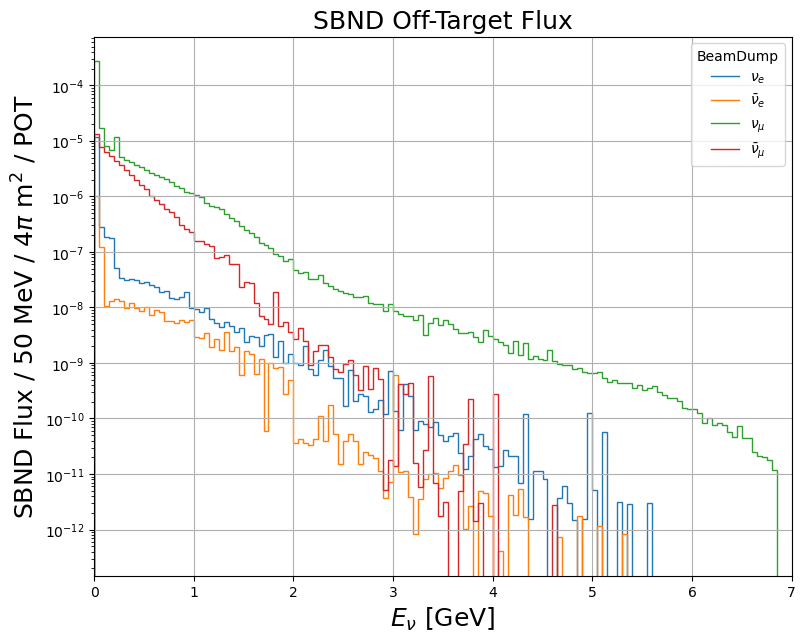

In [26]:
#Josie's flux
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(9, 7))

ax.stairs(sbnd_nue_BDflux, bins, label=r'$\nu_e$')
ax.stairs(sbnd_anue_BDflux, bins, label=r'$\bar{\nu}_e$')
ax.stairs(sbnd_numu_BDflux, bins, label=r'$\nu_\mu$')
ax.stairs(sbnd_anumu_BDflux, bins, label=r'$\bar{\nu}_{\mu}$')

ax.legend(title='BeamDump')
ax.set_xlim([0, 7])
ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title('SBND Off-Target Flux', fontsize=18)
ax.grid(True)
#plt.Show()

/var/folders/08/zf3dmknx5c95wvzr9p4y4l980000gn/T/ipykernel_19557/2189515326.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, loc=2)


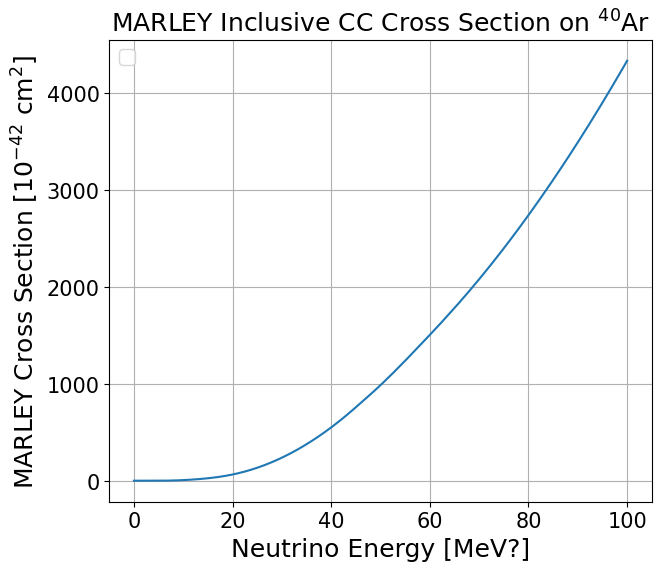

In [45]:
#Steven's xsec spline
xsec_inc = np.loadtxt('/Users/mnebotg/Software/future_runing/beamdump/marley_40Ar_CC_v121_inclusive_xsec.txt', delimiter=" ")

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(7, 6))
ax.plot(xsec_inc[:, 0], xsec_inc[:, 1])#/ 40)

ax.legend(fontsize=14, loc=2)
ax.set_title('MARLEY Inclusive CC Cross Section on $^{40}$Ar', fontsize=18)
ax.set_ylabel(r'MARLEY Cross Section [$10^{-42}$ cm$^2$]',fontsize=18)
ax.set_xlabel('Neutrino Energy [MeV?]',fontsize=18)
ax.tick_params(labelsize=15)
ax.grid(True)
#ax.set_xlim(0, 3)
#ax.set_ylim(0, 3)

In [47]:
rho = 1.38434 #g/cm^{3}
n_a = 6.022e23 #molec/mol
m_mol = 39.95 #g/mol
A = 40
volume_cm3 = 400*400*500

n_targets = (rho * volume_cm3 * n_a * A) / (m_mol)
# n_targets = 4.590389507863089e+31
print('Number of target nucleons: ', n_targets)

Number of target nucleons:  6.677543313141424e+31


In [52]:
bin_centers = (bins[1:] + bins[:-1])/ 2
events = {
    'sbnd_nue_BD': [],
    'sbnd_anue_BD': [],
    'sbnd_numu_BD': [],
    'sbnd_anumu_BD': [],
}
#MARLEY cross section is in units of 10^{-42} cm^2 per nucleon, so we divide by 40 to get per Ar nucleus
Marley_xsec_per_nucleus = 1e-38 / 40

#POT
pot_target = 1.6e20
print('Estimated DB POT:', pot_target)

# nue, SBND BD
for b, f in zip(bin_centers, sbnd_nue_BDflux):

    # Flux per POT target per cm2
    f = f/(4*np.pi) * 1e-4 * pot_target

    # Interpolate the xsec graph at our bin energy
    xsec = np.interp(b, xsec_inc[:,0]/1000, xsec_inc[:,1]*Marley_xsec_per_nucleus)
    
    events['sbnd_nue_BD'].append(f * xsec * n_targets)
print('Estimated SBND nue BD events:', sum(events['sbnd_nue_BD']))
# anue, SBND BD
for b, f in zip(bin_centers, sbnd_anue_BDflux):

    # Flux per POT target per cm2
    f = f/(4*np.pi) * 1e-4 * pot_target

    # Interpolate the xsec graph at our bin energy
    xsec = np.interp(b, xsec_inc[:,0]/1000, xsec_inc[:,1]*Marley_xsec_per_nucleus)
    
    events['sbnd_anue_BD'].append(f * xsec * n_targets) 
print('Estimated SBND anue BD events:', sum(events['sbnd_anue_BD']))

# numu, SBND BD
for b, f in zip(bin_centers, sbnd_numu_BDflux):

    # Flux per POT target per cm2
    f = f/(4*np.pi) * 1e-4 * pot_target

    # Interpolate the xsec graph at our bin energy
    xsec = np.interp(b, xsec_inc[:,0]/1000, xsec_inc[:,1]*Marley_xsec_per_nucleus)
    
    events['sbnd_numu_BD'].append(f * xsec * n_targets) 
print('Estimated SBND numu BD events:', sum(events['sbnd_numu_BD']))    

# anumu, SBND BD
for b, f in zip(bin_centers, sbnd_anumu_BDflux):

    # Flux per POT target per cm2
    f = f/(4*np.pi) * 1e-4 * pot_target

    # Interpolate the xsec graph at our bin energy
    xsec = np.interp(b, xsec_inc[:,0]/1000, xsec_inc[:,1]*Marley_xsec_per_nucleus)
    
    events['sbnd_anumu_BD'].append(f * xsec * n_targets)    
print('Estimated SBND anumu BD events:', sum(events['sbnd_anumu_BD']))


Estimated DB POT: 1.6e+20
Estimated SBND nue BD events: 126996.69717772934
Estimated SBND anue BD events: 26846.502517946254
Estimated SBND numu BD events: 8560276.36891584
Estimated SBND anumu BD events: 3749679.513278356


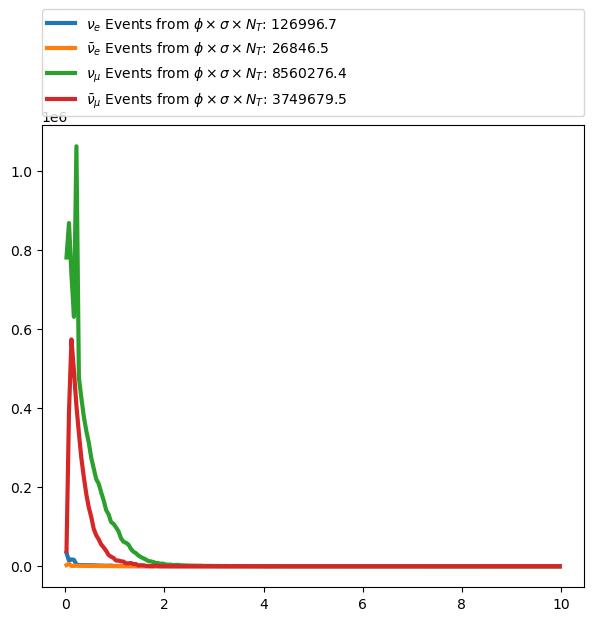

In [53]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(7, 6))
ax.plot(bin_centers, events['sbnd_nue_BD'], color=colors[0], linewidth=3,
        label=r'$\nu_e$ Events from $\phi \times \sigma \times N_T$: ' + f"{np.sum(events['sbnd_nue_BD']):.1f}")

ax.plot(bin_centers, events['sbnd_anue_BD'], color=colors[1], linewidth=3,
        label=r'$\bar{\nu}_e$ Events from $\phi \times \sigma \times N_T$: ' + f"{np.sum(events['sbnd_anue_BD']):.1f}")

ax.plot(bin_centers, events['sbnd_numu_BD'], color=colors[2], linewidth=3,
        label=r'$\nu_\mu$ Events from $\phi \times \sigma \times N_T$: ' + f"{np.sum(events['sbnd_numu_BD']):.1f}")       

ax.plot(bin_centers, events['sbnd_anumu_BD'], color=colors[3], linewidth=3,
        label=r'$\bar{\nu}_\mu$ Events from $\phi \times \sigma \times N_T$: ' + f"{np.sum(events['sbnd_anumu_BD']):.1f}")      

#ax.legend(fontsize=14, loc=1)
ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
          mode="expand", borderaxespad=0, ncol=1)
#ax.set_title('SBND BeamDump Event Rate', fontsize=18)
